# Shap (SHapley Additive exPlanations)

In [50]:
import shap
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Recreate your dataset
X = np.array([[20, 60, 50], [30, 70, 55], [40, 80, 60], [50, 90, 65], [60, 100, 70]])
y = 10 + 0.5 * X[:, 0] + 0.2 * X[:, 1]

# 2. Train a real linear model on your data
model = LinearRegression().fit(X, y)

# 3. Initialize SHAP Explainer with your training data as background
explainer = shap.LinearExplainer(model, X)

# 4. Explain your test sample (Age=35, Weight=73)
X_test = np.array([[35, 73, 58]])
print("model prediction for test data:", model.predict(X_test))
shap_values = explainer(X_test)

print("Base Value (E[f(x)]):", shap_values.base_values[0])
print("SHAP Value for Age:", shap_values.values[0][0])
print("SHAP Value for Weight:", shap_values.values[0][1])
print("SHAP Value for Height:", shap_values.values[0][2])
print("Model Output (f(x)):", shap_values.base_values[0] + shap_values.values[0][0] + shap_values.values[0][1] + shap_values.values[0][2])
print("Model parameters (intercept and coefficient):", model.intercept_, model.coef_)

model prediction for test data: [41.95555556]
Base Value (E[f(x)]): 46.0
SHAP Value for Age: -1.5555555555555556
SHAP Value for Weight: -2.177777777777778
SHAP Value for Height: -0.31111111111111117
Model Output (f(x)): 41.955555555555556
Model parameters (intercept and coefficient): -0.6666666666666714 [0.31111111 0.31111111 0.15555556]


## basic working maths of shap manually

In [ ]:

import numpy as np

age = np.array([20, 30, 40, 50, 60])
weight = np.array([60, 70, 80, 90, 100])
height = np.array([50, 55, 60, 65, 70])

print("Age:", age)
print("Weight:", weight)
print("Height:", height)
print("our linear regression model is: height = -0.667 + (0.311 * age) + (0.311 * weight) + (0.156 * height)")
def model(age, weight, height):
    return -0.667 + .311 * age + .311 * weight + 0.156 * height

x_test_age = np.array([35])
x_test_weight = np.array([73])
x_test_height = np.array([58])

print("x_test_age:", x_test_age)
print("x_test_weight:", x_test_weight)
print("x_test_height:", x_test_height)

y_pred = model(x_test_age, x_test_weight, x_test_height)
print("Predicted output:", y_pred)

Age: [20 30 40 50 60]
Weight: [ 60  70  80  90 100]
Height: [50 55 60 65 70]
our linear regression model is: height = -0.667 + (0.311 * age) + (0.311 * weight) + (0.156 * height)
x_test_age: [35]
x_test_weight: [73]
x_test_height: [58]
Predicted output: [41.969]


In [53]:
y_hats = np.array([])
for i in range(len(age)):
    y_hat = model(age[i], weight[i], height[i])
    y_hats = np.append(y_hats, y_hat)

print("Predicted output for training data:", y_hats)

avg_y_hats = np.mean(y_hats)
print("Average predicted output for training data:", avg_y_hats)

avg_age = np.mean(age)
avg_weight = np.mean(weight)
avg_height = np.mean(height)
print("Average age:", avg_age)
print("Average weight:", avg_weight)
print("Average height:", avg_height)

pred_without_age = y_pred - model(avg_age, x_test_weight, x_test_height)
print("contribution of age to prediction:", pred_without_age)

pred_without_weight =  y_pred - model(x_test_age, avg_weight, x_test_height)
pred_without_height = y_pred - model(x_test_age, x_test_weight, avg_height)
# (10 + 0.5 * x_test_age + 0.2 * avg_weight)
print("contribution of weight to prediction:", pred_without_weight)
print("contribution of height to prediction:", pred_without_height)

print("adding all contributions together:", avg_y_hats + pred_without_age + pred_without_weight + pred_without_height)
print("predicted output for test data:", y_pred)

Predicted output for training data: [32.013 39.013 46.013 53.013 60.013]
Average predicted output for training data: 46.013
Average age: 40.0
Average weight: 80.0
Average height: 60.0
contribution of age to prediction: [-1.555]
contribution of weight to prediction: [-2.177]
contribution of height to prediction: [-0.312]
adding all contributions together: [41.969]
predicted output for test data: [41.969]


In [56]:
# marginal contributions
# step 1. Calculating predictions of all possible subsets of features
# 1.1. empty set
a = model(avg_age, avg_weight, avg_height)
print("model output for empty set (E[f(x)]):", a)

# 1.2. only age
b = model(X_test[0][0], avg_weight, avg_height)
print("model output for only age (E[f(x)|age]):", b)

# 1.3. only weight
c = model(avg_age, X_test[0][1], avg_height)
print("model output for only weight (E[f(x)|weight]):", c)

# 1.4 only height
d = model(avg_age, avg_weight, X_test[0][2])
print("model output for only height (E[f(x)|height]):", d)

# 1.4. both age and weight
e = model(X_test[0][0], X_test[0][1], avg_height)
print("model output for both age and weight (E[f(x)|age,weight]):", e)

# 1.5. both age and height
f = model(X_test[0][0], avg_weight, X_test[0][2])
print("model output for both age and height (E[f(x)|age,height]):", f)

# 1.6. both weight and height
g = model(avg_age, X_test[0][1], X_test[0][2])
print("model output for both weight and height (E[f(x)|weight,height]):", g)

# 1.7. all three
h = model(X_test[0][0], X_test[0][1], X_test[0][2])
print("model output for all three (E[f(x)|age,weight,height]):", h)

model output for empty set (E[f(x)]): 46.013
model output for only age (E[f(x)|age]): 44.458
model output for only weight (E[f(x)|weight]): 43.836
model output for only height (E[f(x)|height]): 45.701
model output for both age and weight (E[f(x)|age,weight]): 42.281
model output for both age and height (E[f(x)|age,height]): 44.146
model output for both weight and height (E[f(x)|weight,height]): 43.524
model output for all three (E[f(x)|age,weight,height]): 41.969


In [58]:
# step 2. Calculating marginal contributions for age

# A marginal contribution is always: [Prediction WITH the feature] \(-\) [Prediction WITHOUT the feature] [1].Because we have two features, 
# Age can be added in two different scenarios (coalitions):

# scenario a: adding age to the empty set
marginal_age_a = b - a
print("Marginal contribution of age in scenario a:", marginal_age_a)

# scenario b: adding age to the coalition of weight
marginal_age_b = e - c
print("Marginal contribution of age in scenario b:", marginal_age_b)

# scenario c: adding age to the coalition of height
marginal_age_c = f - d
print("Marginal contribution of age in scenario c:", marginal_age_c)

# scenario d: adding age to the coalition of weight and height
marginal_age_d = h - g
print("Marginal contribution of age in scenario d:", marginal_age_d)

Marginal contribution of age in scenario a: -1.5549999999999997
Marginal contribution of age in scenario b: -1.5549999999999997
Marginal contribution of age in scenario c: -1.5549999999999997
Marginal contribution of age in scenario d: -1.5549999999999997


In [69]:
# Helper function to calculate the exact formula weight using factorials
import math
def calculate_shapley_weight(subset_size, total_features):
    numerator = math.factorial(subset_size) * math.factorial(total_features - subset_size - 1)
    denominator = math.factorial(total_features)
    return numerator / denominator

# step 3. Calculating the Shapley values for age
weightage_age_a = calculate_shapley_weight(0, 3)
weightage_age_b = calculate_shapley_weight(1, 3)
weightage_age_c = calculate_shapley_weight(1, 3)
weightage_age_d = calculate_shapley_weight(2, 3)

shap_age = (weightage_age_a * marginal_age_a) + (weightage_age_b * marginal_age_b) + (weightage_age_c * marginal_age_c) + (weightage_age_d * marginal_age_d)
print("Shapley values of age:", shap_age)

Shapley values of age: -1.5549999999999997


In [92]:
# step 2. Calculating marginal contributions for weight

# scenario a: adding weight to the empty set
marginal_weight_a = c - a
print("Marginal contribution of weight in scenario a:", marginal_weight_a)

# scenario b: adding weight to the coalition of age
marginal_weight_b = e - b
print("Marginal contribution of weight in scenario b:", marginal_weight_b)

# scenario c: adding weight to the coalition of height
marginal_weight_c = g - d
print("Marginal contribution of weight in scenario c:", marginal_weight_c)

# scenario d: adding weight to the coalition of age and height
marginal_weight_d = h - f
print("Marginal contribution of weight in scenario d:", marginal_weight_d)

Marginal contribution of weight in scenario a: -2.1769999999999996
Marginal contribution of weight in scenario b: -2.1769999999999996
Marginal contribution of weight in scenario c: -2.1769999999999996
Marginal contribution of weight in scenario d: -2.1769999999999996


In [93]:
# Helper function to calculate the exact formula weight using factorials
shap_weight = (weightage_age_a * marginal_weight_a) + (weightage_age_b * marginal_weight_b) + (weightage_age_c * marginal_weight_c) + (weightage_age_d * marginal_weight_d)
print("Shapley values of age:", shap_weight)

Shapley values of age: -2.1769999999999996


In [94]:
# step 2. Calculating marginal contributions for height

# scenario a: adding height to the empty set
marginal_height_a = d - a
print("Marginal contribution of height in scenario a:", marginal_height_a)

# scenario b: adding height to the coalition of weight
marginal_height_b = f - b
print("Marginal contribution of height in scenario b:", marginal_height_b)

# scenario c: adding height to the coalition of age
marginal_height_c = g - c
print("Marginal contribution of height in scenario c:", marginal_height_c)

# scenario d: adding height to the coalition of weight and age
marginal_height_d = h - e
print("Marginal contribution of height in scenario d:", marginal_height_d)

Marginal contribution of height in scenario a: -0.3119999999999976
Marginal contribution of height in scenario b: -0.3119999999999976
Marginal contribution of height in scenario c: -0.3119999999999976
Marginal contribution of height in scenario d: -0.3119999999999976


In [96]:
shap_height = (weightage_age_a * marginal_height_a) + (weightage_age_b * marginal_height_b) + (weightage_age_c * marginal_height_c) + (weightage_age_d * marginal_height_d)
print("Shapley values of age:", shap_height)

Shapley values of age: -0.3119999999999976


all shap values are matching with the actual values in cell 1

In [1]:
import shap
from shap.datasets import iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
x, y = iris(display=False)

In [6]:
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [7]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0, stratify=y)
print(x_train.shape, x_test.shape)

(120, 4) (30, 4)


In [9]:
pd.Series(y_train).value_counts(normalize=True)

0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64

In [10]:
pd.Series(y_test).value_counts(normalize=True)

0    0.333333
1    0.333333
2    0.333333
Name: proportion, dtype: float64

In [11]:
rf = RandomForestClassifier(random_state=0)
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
y_pred_train = rf.predict(x_train)
y_pred_test = rf.predict(x_test)

In [13]:
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)
print("Training Accuracy:", accuracy_train)
print("Testing Accuracy:", accuracy_test)

Training Accuracy: 1.0
Testing Accuracy: 0.9333333333333333


In [14]:
explainer = shap.TreeExplainer(model = rf, data = x_train, model_output = "probability")

In [15]:
# avg predicted probability for each class in the training data
explainer.expected_value

array([0.3601, 0.3293, 0.3106])

In [16]:
# calculating base values manually
rf.predict_proba(x_train).mean(axis=0)

array([0.33341667, 0.33208333, 0.3345    ])

the difference because rf samples first 100 rows and then build the model.

In [ ]:
explainer2 = shap.TreeExplainer(model = rf, data = x_train.iloc[:51], model_output = "probability")

In [18]:
# avg predicted probability for each class in the training data
explainer2.expected_value

array([0.29411765, 0.34607843, 0.35980392])

In [19]:
# calculating base values manually
rf.predict_proba(x_train.iloc[:51]).mean(axis=0)

array([0.29411765, 0.34607843, 0.35980392])

In [20]:
# calcualating shapely values
test_case = x_test.iloc[14:15,:]
display(test_case)

prediction = rf.predict(test_case)
prediction_proba = rf.predict_proba(test_case)
print("Predicted class:", prediction)
print("Predicted probabilities:", prediction_proba)
print("Actual class:", y_test[14])


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
67,5.8,2.7,4.1,1.0


Predicted class: [1]
Predicted probabilities: [[0. 1. 0.]]
Actual class: 1


In [21]:
shap_values = explainer(test_case)
shap_values.shape

(1, 4, 3)

$(1,4,3)$

$1$: number of input rows
$4$: number of features in the input
$3$: number of output classes

In [27]:
shap_values

.values =
array([[[-0.0093    ,  0.04333333, -0.03403333],
        [-0.01275   ,  0.00835   ,  0.0044    ],
        [-0.16903333,  0.28998333, -0.12095   ],
        [-0.16901666,  0.32923333, -0.16021666]]])

.base_values =
array([[0.3601, 0.3293, 0.3106]])

.data =
array([[5.8, 2.7, 4.1, 1. ]])

In [33]:
shap_values.values.round(3)

array([[[-0.009,  0.043, -0.034],
        [-0.013,  0.008,  0.004],
        [-0.169,  0.29 , -0.121],
        [-0.169,  0.329, -0.16 ]]])

`.values`: shap values for first row of data

- `[-0.009, 0.043, -0.034]`: shap values for feature 1
- `[-0.013, 0.008, +0.004]`: shap values for feature 2
- `[-0.169, 0.289, -0.121]`: shap values for feature 3
- `[-0.169, 0.329, -0.160]`: shap values for feature 4

Now, if we consider column wise:
- `[-0.009], [-0.013], [-0.169], [-0.169]`: for output class 0
- `[ 0.043], [ 0.008], [ 0.290], [ 0.329]`: for output class 1
- `[-0.034], [ 0.004], [-0.121], [-0.160]`: for output class 2

In [ ]:
# average or baseline value
explainer.expected_value, shap_values.base_values

(array([0.3601, 0.3293, 0.3106]), array([[0.3601, 0.3293, 0.3106]]))

`0.3601` is for the first class of output
`0.3293` is for the second class of output
`0.3106` is for the third class of output

In [32]:
# this is .data
display(test_case), shap_values.data

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
67,5.8,2.7,4.1,1.0


(None, array([[5.8, 2.7, 4.1, 1. ]]))

In [ ]:
shap_values[0,:,1]

# 0 is the first row of data
# : means all features
# 1 is the output class index (since we have 3 classes, we have indices 0, 1, and 2)

.values =
array([0.04333333, 0.00835   , 0.28998333, 0.32923333])

.base_values =
np.float64(0.32930000000000015)

.data =
array([5.8, 2.7, 4.1, 1. ])

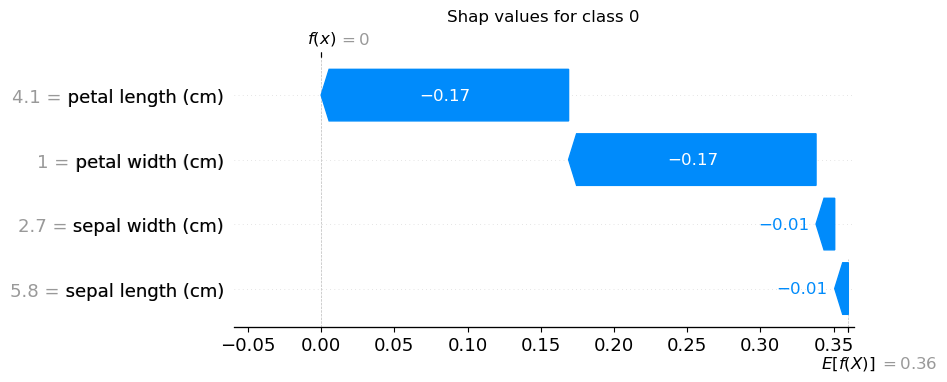

In [58]:
# waterfall plot for class 0
plt.title('Shap values for class 0')
shap.plots.waterfall(shap_values[0,:,0])
plt.show()

In [52]:
(shap_values[0,:,0].base_values + shap_values[0,:,0].values.sum()).round(3)

np.float64(0.0)

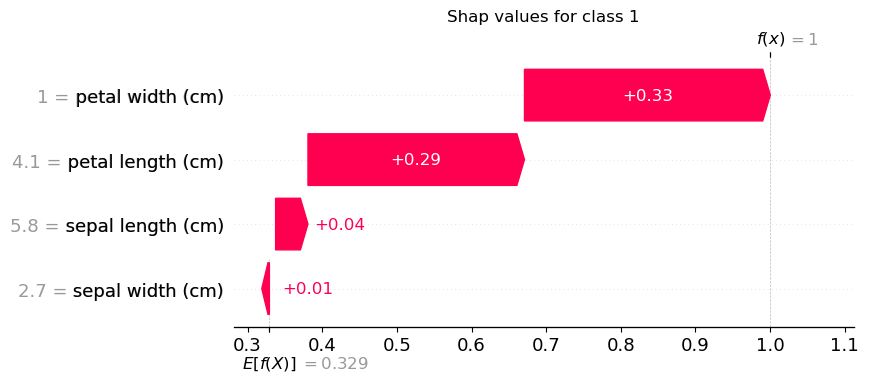

In [57]:
# waterfall plot for class 1
plt.title('Shap values for class 1')
shap.plots.waterfall(shap_values[0,:,1])
plt.show()

In [53]:
(shap_values[0,:,1].base_values + shap_values[0,:,1].values.sum()).round(3)

np.float64(1.0)

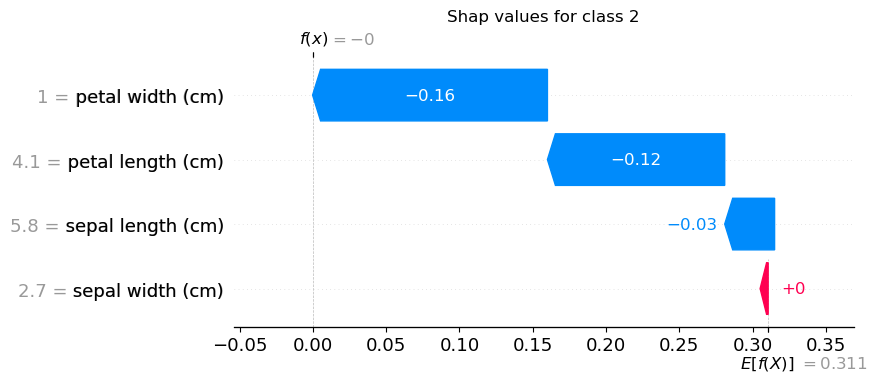

In [59]:
# waterfall plot for class 1
plt.title('Shap values for class 2')
shap.plots.waterfall(shap_values[0,:,2])
plt.show()

In [54]:
(shap_values[0,:,2].base_values + shap_values[0,:,2].values.sum()).round(3)

np.float64(-0.0)